In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output
import time
import imageio
import glob

In [2]:
DTYPE = np.float32

In [ ]:
path = r"\Deep-Learning\datasets\digits"
path_train = path + r'\train.csv'

In [4]:
train_data = np.array(pd.read_csv(path_train))

In [5]:
def normalize_data(data, minimum=0, maximum=1):
    return minimum+((data-np.min(data))/(np.max(data)-np.min(data)))*(maximum-minimum)

In [6]:
def one_hot(data, num_classes=10):
    new_data = np.zeros((data.shape[0], num_classes))
    new_data[np.arange(data.shape[0]), data] = 1
    return new_data

In [7]:
x_data = normalize_data(train_data[:,1:], minimum=-1, maximum=1).astype(DTYPE)
y_data = one_hot(train_data[:, 0], num_classes=10).astype(DTYPE)
print(x_data.shape, y_data.shape)

(42000, 784) (42000, 10)


In [8]:
def ReLU(x, derv=False):
    if derv: return np.where(x>0, 1, 0)
    return np.maximum(x, 0)

In [9]:
def LeakyReLU(x, alpha=0.2, derv=False):
    if derv: return np.where(x>0, 1, alpha)
    return np.where(x>0, x, x*alpha)

In [10]:
def sigmoid(x, derv=False):
    if derv: return x * (1 - x) # x is already calculated as sigmoid
    return 1 / (1 + np.exp(-x))

In [11]:
def tanh(x, derv=False):
    if derv: return 1 - x**2 # x is already calculated as tanh
    return np.tanh(x)

In [12]:
def BCE_loss(y_true, y_pred, epsilon=1e-8, derv=False):
    if derv: return -y_true / (y_pred + epsilon) + (1 - y_true) / (1 - y_pred + epsilon)
    return np.mean(-y_true * np.log(y_pred + epsilon) - (1 - y_true) * np.log(1 - y_pred + epsilon))

In [13]:
n_sound = 100
n_classes = y_data.shape[1]

# Generator: noise + token
n_GINPUT = n_sound + n_classes
n_Ghidden0 = 256
n_Ghidden1 = 512
n_GOUT = x_data.shape[1]

# Discriminator: image + token
n_DINPUT = x_data.shape[1] + n_classes
n_Dhidden0 = 512
n_Dhidden1 = 256
n_DOUT = 1

In [14]:
def generate_classes(total=1, num_classes=10):
    return np.random.randint(low=0, high=num_classes, size=total)

In [15]:
def generate_token(total=1, num_classes=10):
    return one_hot(generate_classes(total=total, num_classes=num_classes), num_classes=num_classes)

In [16]:
def generate_random_input(total):
    noise = np.random.standard_normal(size=(total, n_sound)).astype(DTYPE)
    token = generate_token(total, num_classes=n_classes)
    combined = np.concatenate([noise, token], axis=1)
    return combined, token

In [17]:
num_imgs = 32
seed_tuple = generate_random_input(num_imgs)
seed = seed_tuple[0]
print(seed.shape)

(32, 110)


In [18]:
# Generator
GW0 = np.random.randn(n_GINPUT, n_Ghidden0).astype(DTYPE) * np.sqrt(2/n_GINPUT)
GW1 = np.random.randn(n_Ghidden0, n_Ghidden1).astype(DTYPE) * np.sqrt(2/n_Ghidden0)
GW2 = np.random.randn(n_Ghidden1, n_GOUT).astype(DTYPE) * np.sqrt(1/n_Ghidden1)

Gb0 = np.zeros((1, n_Ghidden0)).astype(DTYPE)
Gb1 = np.zeros((1, n_Ghidden1)).astype(DTYPE)
Gb2 = np.zeros((1, n_GOUT)).astype(DTYPE)

# Discriminator
DW0 = np.random.randn(n_DINPUT, n_Dhidden0).astype(DTYPE) * np.sqrt(2/n_DINPUT)
DW1 = np.random.randn(n_Dhidden0, n_Dhidden1).astype(DTYPE) * np.sqrt(2/n_Dhidden0)
DW2 = np.random.randn(n_Dhidden1, n_DOUT).astype(DTYPE) * np.sqrt(1/n_Dhidden1)

Db0 = np.zeros((1, n_Dhidden0)).astype(DTYPE)
Db1 = np.zeros((1, n_Dhidden1)).astype(DTYPE)
Db2 = np.zeros((1, n_DOUT)).astype(DTYPE)

Generator_parameters = [GW0, Gb0, GW1, Gb1, GW2, Gb2]
Gen_len = len(Generator_parameters)

Discriminator_parameters = [DW0, Db0, DW1, Db1, DW2, Db2]
Disc_len = len(Discriminator_parameters)

In [19]:
# Adam settings for Generator
lr_gen = 1e-3
current_lr_gen = lr_gen
m_gen = [0] * Gen_len
v_gen = [0] * Gen_len
decay_gen = 0
t_gen = 1
beta_1_gen = 0.5
beta_2_gen = 0.999
epsilon_adam_gen = 1e-8

In [20]:
# Adam settings for Discriminator
lr_disc = 1e-3
current_lr_disc = lr_disc
m_disc = [0] * Disc_len
v_disc = [0] * Disc_len
decay_disc = 0
t_disc = 1
beta_1_disc = 0.5
beta_2_disc = 0.999
epsilon_adam_disc = 1e-8

In [21]:
def adam_optimizer(grads, m, v, beta_1, beta_2, t, epsilon, i):
    m[i] = beta_1 * m[i] + (1 - beta_1) * grads
    v[i] = beta_2 * v[i] + (1 - beta_2) * grads**2
    m_h = m[i] / (1 - beta_1**t)
    v_h = v[i] / (1 - beta_2**t)
    return m_h / (np.sqrt(v_h) + epsilon)

In [22]:
def step(network):
    if network == 'G':
        global t_gen
        t_gen += 1
    else:
        global t_disc
        t_disc += 1

In [23]:
def prev_update(network):
    if network == 'G':
        global current_lr_gen
        if decay_gen:
            current_lr_gen = lr_gen * (1 / (1 + t_gen * decay_gen))
    else:
        global current_lr_disc
        if decay_disc:
            current_lr_disc = lr_disc * (1 / (1 + t_disc * decay_disc))

In [24]:
def update_params(network, gradients):
    prev_update(network)
    if network == 'G':
        for i in range(Gen_len):
            Generator_parameters[i] -= current_lr_gen * adam_optimizer(gradients[i], m_gen, v_gen, beta_1_gen, beta_2_gen, t_gen, epsilon_adam_gen, i)
    else:
        for i in range(Disc_len):
            Discriminator_parameters[i] -= current_lr_disc * adam_optimizer(gradients[i], m_disc, v_disc, beta_1_disc, beta_2_disc, t_disc, epsilon_adam_disc, i)
    step(network)

In [25]:
def forward_generator(w):
    global Gz0, Ga0, Gz1, Ga1, Gz2, Ga2

    Gz0 = w @ GW0 + Gb0
    Ga0 = ReLU(Gz0)

    Gz1 = Ga0 @ GW1 + Gb1
    Ga1 = ReLU(Gz1)

    Gz2 = Ga1 @ GW2 + Gb2
    Ga2 = tanh(Gz2)
    
    return Ga2

In [26]:
def forward_discriminator(x, token):
    global input_disc, Dz0, Da0, Dz1, Da1, Dz2, Da2

    input_disc = np.concatenate([x, token], axis=1)
    
    Dz0 = input_disc @ DW0 + Db0
    Da0 = LeakyReLU(Dz0)

    Dz1 = Da0 @ DW1 + Db1
    Da1 = LeakyReLU(Dz1)

    Dz2 = Da1 @ DW2 + Db2
    Da2 = sigmoid(Dz2)

    return Da2

In [27]:
def backward_discriminator(y=None, outp=None, deltas=None, learn=True):
    if y is not None:
        dL = BCE_loss(y, outp, derv=True)
    elif deltas is not None:
        dL = deltas
    else: raise ValueError("there is no (y) or (deltas)")
    m = dL.shape[0]
    dL *= sigmoid(outp, derv=True)

    dDW2 = Da1.T @ dL / m
    dDb2 = np.sum(dL, axis=0, keepdims=True) / m

    dDa1 = dL @ DW2.T
    dDz1 = dDa1 * LeakyReLU(Dz1, derv=True)

    dDW1 = Da0.T @ dDz1 / m
    dDb1 = np.sum(dDz1, axis=0, keepdims=True) / m

    dDa0 = dDz1 @ DW1.T
    dDz0 = dDa0 * LeakyReLU(Dz0, derv=True)
    
    dDW0 = input_disc.T @ dDz0 / m
    dDb0 = np.sum(dDz0, axis=0, keepdims=True) / m

    deltas = dDz0 @ DW0.T

    gradients = dDW0, dDb0, dDW1, dDb1, dDW2, dDb2

    if learn:
        update_params('D', gradients)

    return deltas

In [28]:
def backward_generator(x=None, y=None, outp=None, deltas=None, learn=True):
    if y is not None:
        dL = BCE_loss(y, outp, derv=True)
    elif deltas is not None:
        dL = deltas[:, :n_GOUT]
    else: raise ValueError("there is no (y) or (deltas)")
    m = dL.shape[0]
    dL *= tanh(outp, derv=True)

    dGW2 = Ga1.T @ dL / m
    dGb2 = np.sum(dL, axis=0, keepdims=True) / m

    dGa1 = dL @ GW2.T
    dGz1 = dGa1 * ReLU(Gz1, derv=True)

    dGW1 = Ga0.T @ dGz1 / m
    dGb1 = np.sum(dGz1, axis=0, keepdims=True) / m

    dGa0 = dGz1 @ GW1.T
    dGz0 = dGa0 * ReLU(Gz0, derv=True)

    dGW0 = x.T @ dGz0 / m
    dGb0 = np.sum(dGz0, axis=0, keepdims=True) / m

    gradients = dGW0, dGb0, dGW1, dGb1, dGW2, dGb2

    if learn:
        update_params('G', gradients)

    return None

In [ ]:
EPOCHS = 100
BATCH_SIZE = 256
ALR_EPOCHS = 0
imgs_path = r'\Deep-Learning\Python\only_numpy\no_oop\GANs\digits_conditionalgan'

In [30]:
def generate_and_save_images(epoch, gen_loss, disc_loss):
    clear_output(wait=True)
    generated_imgs = forward_generator(seed)
    if not os.path.exists(imgs_path):
        os.makedirs(imgs_path)
    rows = cols = int(seed.shape[0]**0.5)
    if rows * cols < num_imgs:
        cols += 1
    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    fig.suptitle(f'Epoch: {epoch}, Gen Loss: {gen_loss:.4f}, Disc Loss: {disc_loss:.4f}', fontsize=12)
    for i, ax in enumerate(axes.flat):
        if i < num_imgs:
            ax.imshow(generated_imgs[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
    plt.savefig(os.path.join(imgs_path, f'generated_images_epoch_{epoch}.png'))
    plt.show()

In [31]:
def train_GAN(x, y, epochs, batch_size, d_steps=1, g_steps=2, alpha=1, beta=1, verbose=True, debug=False):
    global ALR_EPOCHS
    half_batch = batch_size // 2

    for ep in range(1, epochs + 1):
        start = time.time()

        for b in range(0, x.shape[0], half_batch):
            current_half = min(half_batch, x[b:b+half_batch].shape[0])
            real_data = x[b:b+current_half]
            real_token = y[b:b+current_half]

            for _ in range(d_steps):
                noise_fake, token_fake = generate_random_input(total=current_half)
                fake_data = forward_generator(noise_fake)

                total_data = np.concatenate([real_data, fake_data], axis=0)
                total_token = np.concatenate([real_token, token_fake], axis=0)

                real_labels = np.ones((current_half, 1)) * alpha
                fake_labels = np.zeros((current_half, 1))
                total_labels = np.concatenate([real_labels, fake_labels], axis=0)

                predictions = forward_discriminator(total_data, total_token)
                disc_loss = BCE_loss(total_labels, predictions)
                backward_discriminator(total_labels, predictions, learn=True)

            for _ in range(g_steps):
                noise_gen, token_gen = generate_random_input(total=batch_size)
                fake_data = forward_generator(noise_gen)
                true_labels = np.ones((batch_size, 1)) * beta
                predictions = forward_discriminator(fake_data, token_gen)
                gen_loss = BCE_loss(true_labels, predictions)
                deltas = backward_discriminator(true_labels, predictions,learn=False)
                backward_generator(noise_gen, outp=fake_data, deltas=deltas)

            if debug:
                print(f"gen_loss: {gen_loss:.4f} / disc_loss: {disc_loss:.4f}")

        if verbose:
            end = time.time()
            generate_and_save_images(ep+ALR_EPOCHS, gen_loss, disc_loss)
            print(f'digits GAN -> Epoch: [{ep}/{epochs}] (in {end - start:.4f} sec) gen_loss: {gen_loss:.4f} / disc_loss: {disc_loss:.4f}')

    ALR_EPOCHS += epochs

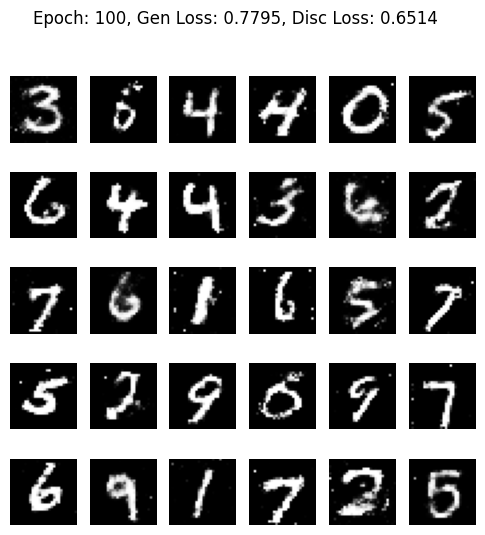

digits GAN -> Epoch: [100/100] (in 83.6511 sec) gen_loss: 0.7795 / disc_loss: 0.6514


In [32]:
train_GAN(
    x=x_data,
    y=y_data,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    d_steps=1,
    g_steps=2,
    alpha=0.99,
    beta=1,
    verbose=True,
    debug=False
)

In [ ]:
pattern = os.path.join(imgs_path, 'generated_images_epoch_*.png')
img_files = sorted(glob.glob(pattern), key=lambda x: int(x.split('_')[-1].split('.')[0]))

images = [imageio.imread(img) for img in img_files]
gif_filename = os.path.join(imgs_path, 'training.gif')
imageio.mimsave(gif_filename, images, duration=0.5)
print("GIF guardado como:", gif_filename)

In [34]:
def generate_digit_input(digit, total=1):
    noise = np.random.standard_normal(size=(total, n_sound)).astype(DTYPE)
    token = np.zeros((total, n_classes), dtype=DTYPE)
    token[:, digit] = 1
    combined = np.concatenate([noise, token], axis=1)
    return combined, token

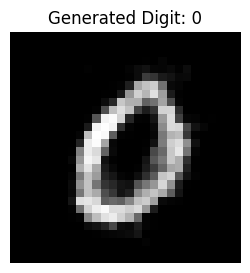

In [47]:
desired_digit = 0
input_combined, token_dummy = generate_digit_input(desired_digit, total=1)
generated_img = forward_generator(input_combined)

plt.figure(figsize=(3, 3))
plt.title(f'Generated Digit: {desired_digit}')
plt.imshow(generated_img[0].reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()